## Notebook for preprocessing of Joung2023 dataset

Step 0 (base dataset): Start from TFAtlas_raw

Step 1 (selection): QC, cap cells per TF (max 1000, min 100). Retain mCherry and GFP so that they are 25% of the final dataset

Step 3 (preprocessing): keep raw counts, normalize + log1p

Step 4 (controls): check whether to merge GFP and mCherry

Step 5 (annotation enrichment), add: TF identity, is_differentiated, is_combinatorial_tested

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad
import scanpy as sc

In [ ]:

adata_file = '../../../data/real/Joung2023/GSE217460_210322_TFAtlas_raw.h5ad'
adata_differentiated_file = '../../../data/real/Joung2023/GSE217460_210322_TFAtlas_differentiated_raw.h5ad'
adata_combinatorial_file = '../../../data/real/Joung2023/GSE217066_210715_combinatorial_subsample.h5ad'
result_folder = '../../../data/real/Joung2023/'
max_num_cells_per_tf = 1000
min_num_cells_per_tf = 500
num_ctrl_cells = 10000 # 460962 / 3 # total for both mCherry and  GFP
seed = 42

In [3]:
adata = sc.read_h5ad(adata_file)

In [4]:
adata

AnnData object with n_obs × n_vars = 1145823 × 37528
    obs: 'n_genes', 'percent_mito', 'n_counts', 'batch', 'TF'
    var: 'n_cells-0-0', 'n_cells-0-1-0', 'n_cells-1-1-0', 'n_cells-2-1-0', 'n_cells-3-1-0', 'n_cells-0-2-0', 'n_cells-1-2-0', 'n_cells-2-2-0', 'n_cells-3-2-0', 'n_cells-0-3-0', 'n_cells-1-3-0', 'n_cells-2-3-0', 'n_cells-3-3-0', 'n_cells-0-4-0', 'n_cells-1-4-0', 'n_cells-2-4-0', 'n_cells-3-4-0', 'n_cells-0-1', 'n_cells-1-1', 'n_cells-2-1', 'n_cells-3-1'

In [5]:
adata.obs

,n_genes,percent_mito,n_counts,batch,TF
"R1.01,R2.01,R3.01,P1.22-0-0",1642,0.030650,2186.0,0,TFORF0867-NR1H2
"R1.01,R2.01,R3.02,P1.22-0-0",1892,0.023033,2605.0,0,TFORF1728-ZNF695
"R1.01,R2.01,R3.05,P1.38-0-0",2159,0.027615,3078.0,0,TFORF0131-HMGB4
"R1.01,R2.01,R3.09,P1.46-0-0",2193,0.025601,3164.0,0,TFORF2044-ARID3C
"R1.01,R2.01,R3.10,P1.22-0-0",1276,0.026415,1590.0,0,TFORF0422-PBX2
...,...,...,...,...,...
"R1.96,R2.96,R3.45,P1.62-3-1",2690,0.018698,4225.0,1,TFORF3550-mCherry
"R1.96,R2.96,R3.58,P1.62-3-1",1971,0.018634,2737.0,1,TFORF3550-mCherry
"R1.96,R2.96,R3.79,P1.62-3-1",2392,0.019268,3581.0,1,TFORF3550-mCherry
"R1.96,R2.96,R3.85,P1.62-3-1",2849,0.023794,4581.0,1,TFORF0512-TSHZ1


In [6]:
adata.obs[['ORF_ID', 'TF_name']]= adata.obs['TF'].str.split('-', n=1, expand=True)

In [7]:
adata_differentiated = sc.read_h5ad(adata_differentiated_file)
adata_combinatorial = sc.read_h5ad(adata_combinatorial_file)

In [8]:
adata.obs['is_differentiated'] = adata.obs_names.isin(adata_differentiated.obs_names)

In [9]:
adata_combinatorial = adata_combinatorial[adata_combinatorial.obs['TF'].str.count(',') == 1, :]
adata_combinatorial.obs[['TF1', 'TF2']] = adata_combinatorial.obs['TF'].str.split(',', n=1, expand=True)
adata_combinatorial.obs[['ORF_ID1', 'TF_name1']] = adata_combinatorial.obs['TF1'].str.split('-', n=1, expand=True)
adata_combinatorial.obs[['ORF_ID2', 'TF_name2']] = adata_combinatorial.obs['TF2'].str.split('-', n=1, expand=True)
double_intervened_tfs = list(set(adata_combinatorial.obs['TF_name1'].unique()).union(set(adata_combinatorial.obs['TF_name2'].unique())))


/tmp/ipykernel_2948115/1928108081.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_combinatorial.obs[['TF1', 'TF2']] = adata_combinatorial.obs['TF'].str.split(',', n=1, expand=True)


In [10]:
adata.obs['is_combinatorially_tested'] = adata.obs['TF_name'].isin(double_intervened_tfs)
adata.obs['is_combinatorially_tested'].sum()

np.int64(66451)

In [11]:
adata.obs.loc[:, ['n_counts', 'n_genes', 'percent_mito']].agg(['min', 'max'], numeric_only=True)
# no need for QC

,n_counts,n_genes,percent_mito
min,769.0,700,0.002822
max,14973.0,6061,0.049968


In [12]:
tf_name_counts = adata.obs['TF_name'].value_counts()
to_remove = tf_name_counts[tf_name_counts < min_num_cells_per_tf].index
adata = adata[~adata.obs['TF_name'].isin(to_remove), :]

In [13]:
diff_stats = adata.obs.groupby('TF_name')['is_differentiated'].agg(['sum', 'count'])
diff_stats.columns = ['n_differentiated', 'n_total']
diff_stats['n_non_differentiated'] = diff_stats['n_total'] - diff_stats['n_differentiated']
diff_stats['frac_differentiated'] = diff_stats['n_differentiated'] / diff_stats['n_total']

all_diff = (diff_stats['n_non_differentiated'] == 0).sum()
all_non_diff = (diff_stats['n_differentiated'] == 0).sum()
mixed = ((diff_stats['n_differentiated'] > 0) & (diff_stats['n_non_differentiated'] > 0)).sum()

print(f"TFs with ALL cells differentiated:     {all_diff}")
print(f"TFs with NO cells differentiated:      {all_non_diff}")
print(f"TFs with MIXED differentiation status: {mixed}")
#diff_stats.sort_values('frac_differentiated', ascending=False)
print(diff_stats.sort_values('frac_differentiated', ascending=False))
print('Frac differentiated stats:')
print(diff_stats['frac_differentiated'].describe())

TFs with ALL cells differentiated:     0
TFs with NO cells differentiated:      0
TFs with MIXED differentiation status: 382
         n_differentiated  n_total  n_non_differentiated  frac_differentiated
TF_name                                                                      
KLF2                  408     1306                   898             0.312404
T                     155      569                   414             0.272408
KLF5                  704     2605                  1901             0.270250
MSGN1                 252      959                   707             0.262774
ASCL3                 199      833                   634             0.238896
...                   ...      ...                   ...                  ...
ZNF789                 28     5201                  5173             0.005384
CAMTA1                 50    10322                 10272             0.004844
NHP2                   43    14339                 14296             0.002999
GFP              

In [ ]:
def subsample_tf(group, max_cells, seed=42):
    
    if len(group) <= max_cells:
        return group
    
    selected = [group.sample(n=max_cells, random_state=seed)]
    
    return pd.concat(selected)

keep_idx = (
    adata.obs
    .groupby('TF_name', group_keys=False)
    .apply(lambda g: subsample_tf(g, max_num_cells_per_tf))
    .index
)

intervention_adata = adata[keep_idx, :] # type: ignore
intervention_adata = intervention_adata[~(intervention_adata.obs['TF_name'] == 'mCherry'), :]
intervention_adata = intervention_adata[~(intervention_adata.obs['TF_name'] == 'GFP'), :]
print(intervention_adata.obs['TF_name'].value_counts().describe())

/tmp/ipykernel_2948115/4196498178.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: subsample_tf(g, max_num_cells_per_tf))


count     380.000000
mean      891.489474
std       168.558415
min       501.000000
25%       784.750000
50%      1000.000000
75%      1000.000000
max      1000.000000
Name: count, dtype: float64


In [15]:
ctrl_cells = adata.obs[(adata.obs['TF_name'] == 'mCherry') | (adata.obs['TF_name'] == 'GFP')]
selected_idx = ctrl_cells.sample(n=num_ctrl_cells, random_state=seed).index
ctrl_cells = adata[selected_idx, :] 
ctrl_cells

View of AnnData object with n_obs × n_vars = 10000 × 37528
    obs: 'n_genes', 'percent_mito', 'n_counts', 'batch', 'TF', 'ORF_ID', 'TF_name', 'is_differentiated', 'is_combinatorially_tested'
    var: 'n_cells-0-0', 'n_cells-0-1-0', 'n_cells-1-1-0', 'n_cells-2-1-0', 'n_cells-3-1-0', 'n_cells-0-2-0', 'n_cells-1-2-0', 'n_cells-2-2-0', 'n_cells-3-2-0', 'n_cells-0-3-0', 'n_cells-1-3-0', 'n_cells-2-3-0', 'n_cells-3-3-0', 'n_cells-0-4-0', 'n_cells-1-4-0', 'n_cells-2-4-0', 'n_cells-3-4-0', 'n_cells-0-1', 'n_cells-1-1', 'n_cells-2-1', 'n_cells-3-1'

In [ ]:
#full_adata = adata
adata = ad.concat([intervention_adata, ctrl_cells], axis=0)

In [18]:
adata

AnnData object with n_obs × n_vars = 348766 × 37528
    obs: 'n_genes', 'percent_mito', 'n_counts', 'batch', 'TF', 'ORF_ID', 'TF_name', 'is_differentiated', 'is_combinatorially_tested'

In [19]:
adata.write_h5ad(f'{result_folder}Joung2023_before_preprocessing.h5ad')

In [20]:
# Store raw counts before any normalization
adata.layers['counts'] = adata.X.copy()

# Normalize and log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Store normalized+log1p before HVG subsetting and scaling
adata.layers['lognorm'] = adata.X.copy()

# HVG selection on normalized+log data
sc.pp.highly_variable_genes(adata, n_top_genes=5000, batch_key='batch', subset=False)
print(f"HVGs selected: {adata.var['highly_variable'].sum()}")

# Limit to HVGs for PCA
adata = adata[:, adata.var['highly_variable']]

# Scale and run PCA
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50, svd_solver='arpack')

# Restore X to lognorm values (HVG subset)
adata.X = adata.layers['lognorm'].copy()

# UMAP (via neighbors graph)
sc.pp.neighbors(adata, n_pcs=50)
sc.tl.umap(adata)

adata

HVGs selected: 5000


/home/laganiv/miniconda3/envs/deep_learning/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


AnnData object with n_obs × n_vars = 348766 × 5000
    obs: 'n_genes', 'percent_mito', 'n_counts', 'batch', 'TF', 'ORF_ID', 'TF_name', 'is_differentiated', 'is_combinatorially_tested'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'lognorm'
    obsp: 'distances', 'connectivities'

## Step 4: Controls — check mCherry vs GFP overlap on UMAP

TF_name
mCherry    6080
GFP        3920
Name: count, dtype: int64


/tmp/ipykernel_2948115/3750771378.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for tf, grp in adata_ctrl.obs.groupby('TF_name'):


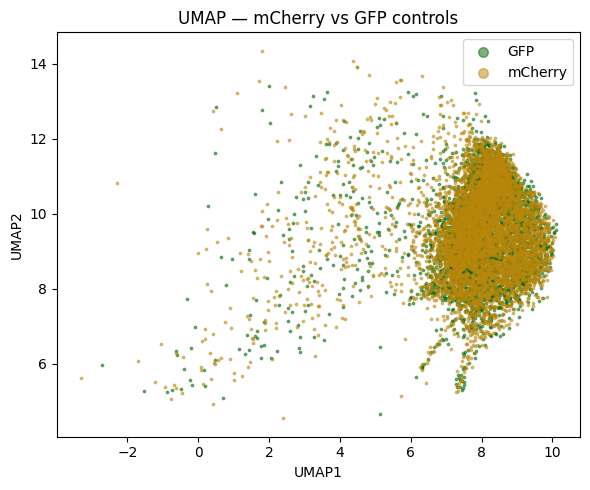

In [22]:
import matplotlib.pyplot as plt

controls = ['mCherry', 'GFP']
adata_ctrl = adata[adata.obs['TF_name'].isin(controls)]
print(adata_ctrl.obs['TF_name'].value_counts())

fig, ax = plt.subplots(figsize=(6, 5))
colors = {'mCherry': '#B8860B', 'GFP': '#006400'}
for tf, grp in adata_ctrl.obs.groupby('TF_name'):
    umap_coords = adata_ctrl[grp.index].obsm['X_umap']
    ax.scatter(umap_coords[:, 0], umap_coords[:, 1],
               c=colors[tf], label=tf, s=3, alpha=0.5)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.legend(markerscale=4)
ax.set_title('UMAP — mCherry vs GFP controls')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2948115/3234405918.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diff_frac = adata.obs.groupby('TF_name')['is_differentiated'].mean()


Plotting 85 groups: controls + 83 TFs


/tmp/ipykernel_2948115/3234405918.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm', len(selected_tfs))
/tmp/ipykernel_2948115/3234405918.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for tf, grp in adata_plot.obs.groupby('TF_name'):
/tmp/ipykernel_2948115/3234405918.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


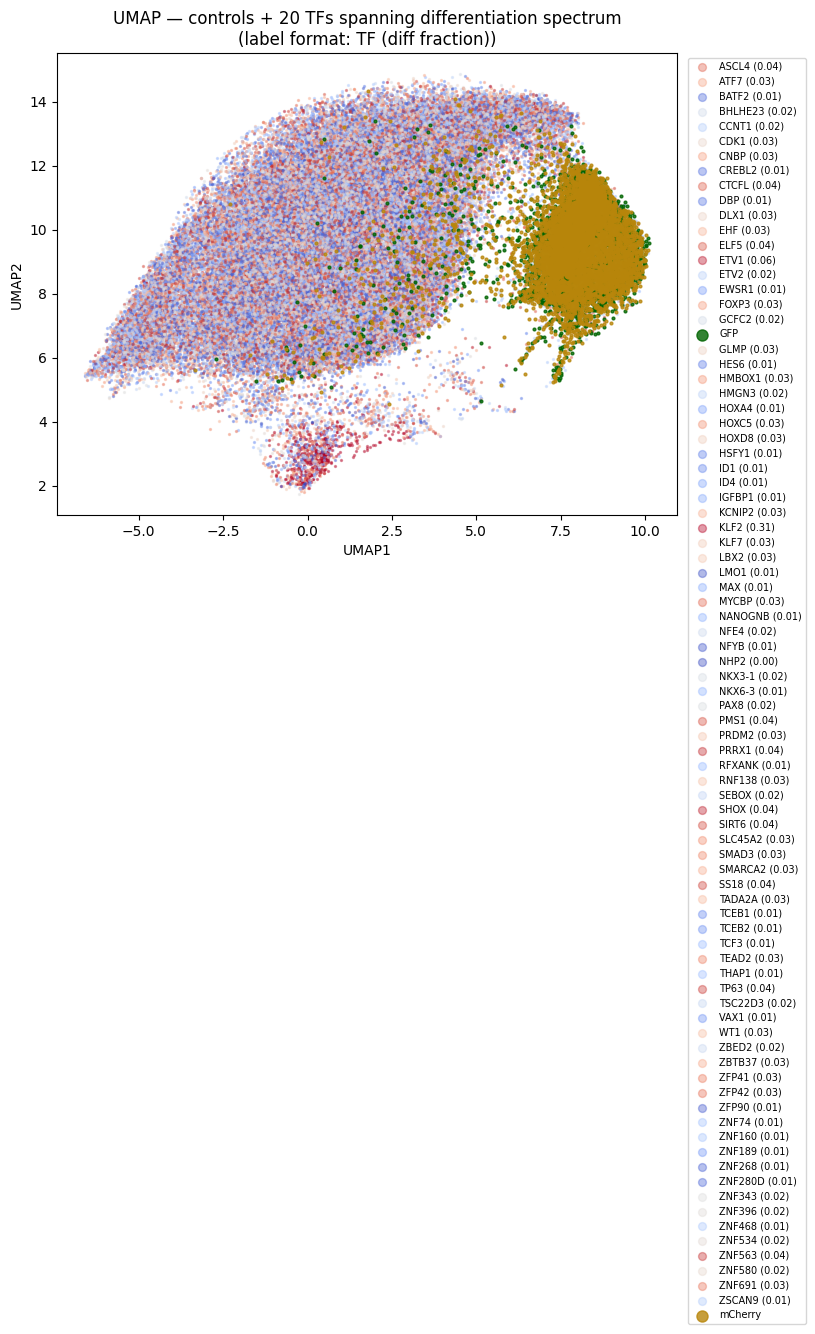

In [23]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Select 20 TFs spanning the full range of differentiation fraction
diff_frac = adata.obs.groupby('TF_name')['is_differentiated'].mean()
diff_frac = diff_frac.drop(labels=['mCherry', 'GFP'], errors='ignore')
selected_tfs = diff_frac.quantile(np.linspace(0, 1, 20), interpolation='nearest').drop_duplicates().values.tolist()
selected_tfs = diff_frac[diff_frac.isin(selected_tfs)].index.tolist()
plot_tfs = ['mCherry', 'GFP'] + selected_tfs
print(f"Plotting {len(plot_tfs)} groups: controls + {len(selected_tfs)} TFs")

adata_plot = adata[adata.obs['TF_name'].isin(plot_tfs)]

# Color controls distinctly; TFs by a continuous colormap based on diff fraction
cmap = cm.get_cmap('coolwarm', len(selected_tfs))
tf_colors = {tf: cmap(i) for i, tf in enumerate(sorted(selected_tfs, key=lambda t: diff_frac[t]))}
tf_colors['mCherry'] = '#B8860B'  # dark yellow
tf_colors['GFP'] = '#006400'      # dark green

fig, ax = plt.subplots(figsize=(8, 6))
for tf, grp in adata_plot.obs.groupby('TF_name'):
    coords = adata_plot[grp.index].obsm['X_umap']
    is_control = tf in ('mCherry', 'GFP')
    frac = diff_frac.get(tf, float('nan'))
    label = tf if is_control else f"{tf} ({frac:.2f})"
    ax.scatter(coords[:, 0], coords[:, 1],
               c=[tf_colors[tf]], label=label,
               s=4 if is_control else 2,
               alpha=0.8 if is_control else 0.4,
               zorder=3 if is_control else 1)

ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('UMAP — controls + 20 TFs spanning differentiation spectrum\n(label format: TF (diff fraction))')
ax.legend(markerscale=4, fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [24]:
adata.obs['control_type'] = adata.obs['TF_name'].where(adata.obs['TF_name'].isin(['mCherry', 'GFP']), other=None)
adata.obs['TF_name'] = adata.obs['TF_name'].replace({'mCherry': 'ctrl', 'GFP': 'ctrl'})

print(adata.obs['control_type'].value_counts(dropna=False))
print(adata.obs['TF_name'].value_counts().head())

control_type
NaN        338766
mCherry      6080
GFP          3920
SPIB            0
SPDEF           0
            ...  
IL18            0
IKZF3           0
IKZF1           0
IGFBP1          0
KCNIP2          0
Name: count, Length: 383, dtype: int64
TF_name
ctrl      10000
ZSCAN9     1000
ZNF821     1000
ZSCAN2     1000
ZNF789     1000
Name: count, dtype: int64


/tmp/ipykernel_2948115/3069048171.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['TF_name'] = adata.obs['TF_name'].replace({'mCherry': 'ctrl', 'GFP': 'ctrl'})


In [25]:
adata.write_h5ad(result_folder + 'Joung2023.h5ad')
print(f"Saved to {result_folder}Joung2023.h5ad")

Saved to ../../../data/real/Joung2023_random_subsample/Joung2023.h5ad
